# 🏝️ EDA - Sistem Rekomendasi Tempat Wisata Indonesia
**Dataset:** Indonesia Tourism Destination (Kaggle - aprabowo)

Notebook ini berisi Exploratory Data Analysis (EDA) sebagai tahap awal sebelum membangun sistem rekomendasi.

## 📦 1. Install & Import Library

In [1]:
# Install library yang dibutuhkan
!pip install pandas numpy matplotlib seaborn wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Setting tampilan
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ Library berhasil diimport!')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Library berhasil diimport!


## 📂 2. Load Dataset

> **Catatan:** Upload file CSV ke Google Colab terlebih dahulu:
> - Klik ikon folder di sebelah kiri
> - Klik tombol upload
> - Upload keempat file CSV dari dataset

In [2]:
# Load semua file dataset
tourism = pd.read_csv('tourism_with_id.csv')
rating  = pd.read_csv('tourism_rating.csv')
user    = pd.read_csv('user.csv')
package = pd.read_csv('package_tourism.csv')

print('✅ Dataset berhasil dimuat!')
print(f'   tourism_with_id : {tourism.shape[0]} baris, {tourism.shape[1]} kolom')
print(f'   tourism_rating  : {rating.shape[0]} baris, {rating.shape[1]} kolom')
print(f'   user            : {user.shape[0]} baris, {user.shape[1]} kolom')
print(f'   package_tourism : {package.shape[0]} baris, {package.shape[1]} kolom')

✅ Dataset berhasil dimuat!
   tourism_with_id : 437 baris, 13 kolom
   tourism_rating  : 10000 baris, 3 kolom
   user            : 300 baris, 3 kolom
   package_tourism : 100 baris, 7 kolom


## 🔍 3. Eksplorasi Awal Dataset Utama

In [3]:
# Tampilkan 5 data pertama
print('=== 5 Data Pertama tourism_with_id.csv ===')
tourism.head()

=== 5 Data Pertama tourism_with_id.csv ===


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156,NaN,4
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5


In [4]:
# Informasi tipe data
print('=== Informasi Kolom ===')
tourism.info()

=== Informasi Kolom ===
<class 'pandas.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    str    
 2   Description   437 non-null    str    
 3   Category      437 non-null    str    
 4   City          437 non-null    str    
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    str    
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   437 non-null    int64  
dtypes: float64(5), int64(3), str(5)
memory usage: 44.5 KB


In [5]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
tourism[['Rating', 'Price']].describe().round(2)

=== Statistik Deskriptif ===


,Rating,Price
count,437.00,437.00
mean,4.44,24652.17
std,0.21,66446.37
min,3.40,0.00
25%,4.30,0.00
50%,4.50,5000.00
75%,4.60,20000.00
max,5.00,900000.00


## 🧹 4. Cek Missing Values & Data Duplikat

In [6]:
print('=== Missing Values ===')
missing = tourism.isnull().sum()
missing_pct = (missing / len(tourism) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])

print(f'\n=== Data Duplikat ===')
print(f'Jumlah duplikat: {tourism.duplicated().sum()}')

print(f'\n=== Kolom Tidak Relevan ===')
print('Kolom Unnamed: 11 dan Unnamed: 12 akan dihapus saat preprocessing')

=== Missing Values ===
              Jumlah Missing  Persentase (%)
Time_Minutes             232           53.09
Unnamed: 11              437          100.00

=== Data Duplikat ===
Jumlah duplikat: 0

=== Kolom Tidak Relevan ===
Kolom Unnamed: 11 dan Unnamed: 12 akan dihapus saat preprocessing


## 📊 5. Distribusi Kategori Wisata

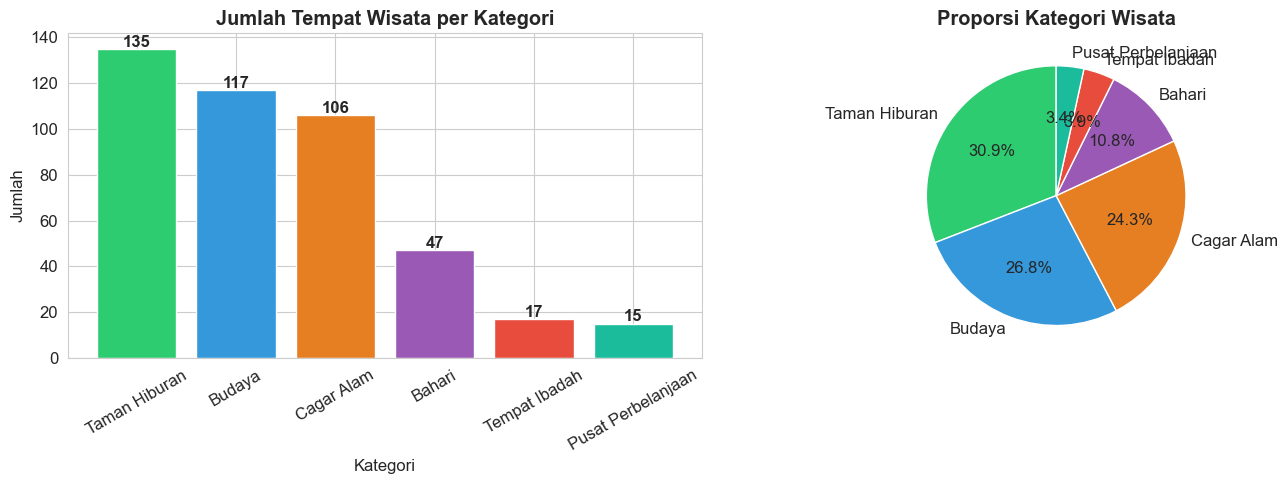


📌 Insight: Taman Hiburan mendominasi dataset (30.9%), diikuti Budaya (26.8%) dan Cagar Alam (24.3%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
kategori = tourism['Category'].value_counts()
colors = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6', '#e74c3c', '#1abc9c']
axes[0].bar(kategori.index, kategori.values, color=colors)
axes[0].set_title('Jumlah Tempat Wisata per Kategori', fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(kategori.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(kategori.values, labels=kategori.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proporsi Kategori Wisata', fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Taman Hiburan mendominasi dataset (30.9%), diikuti Budaya (26.8%) dan Cagar Alam (24.3%)')

## 🏙️ 6. Distribusi Kota

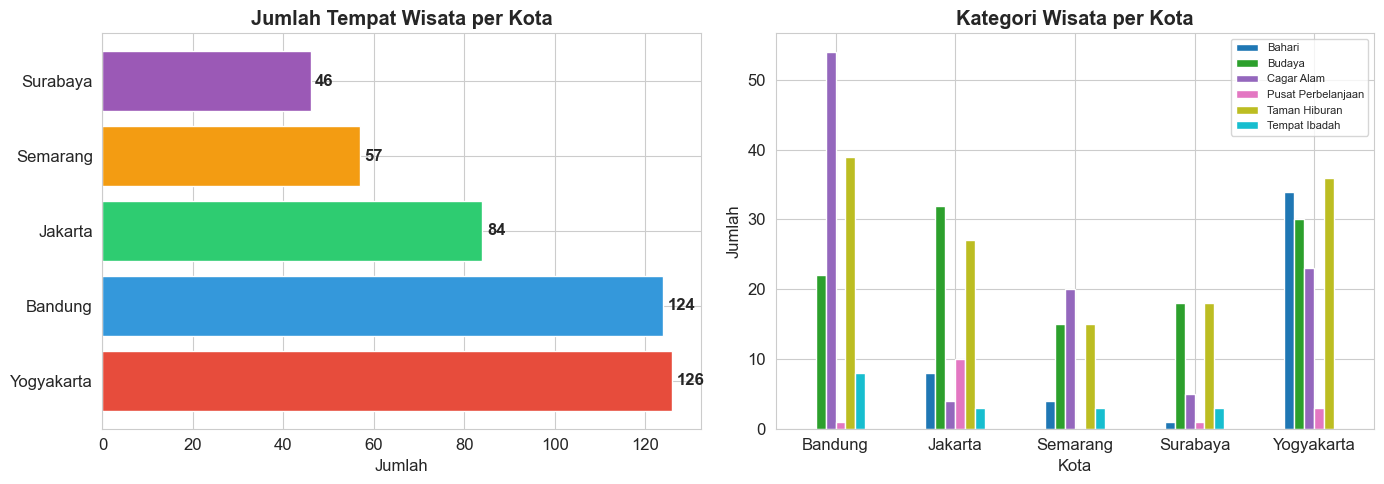


📌 Insight: Yogyakarta dan Bandung memiliki jumlah destinasi terbanyak


In [8]:
kota = tourism['City'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart kota
colors_kota = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
axes[0].barh(kota.index, kota.values, color=colors_kota)
axes[0].set_title('Jumlah Tempat Wisata per Kota', fontweight='bold')
axes[0].set_xlabel('Jumlah')
for i, v in enumerate(kota.values):
    axes[0].text(v + 1, i, str(v), va='center', fontweight='bold')

# Kategori per kota (stacked bar)
kota_kategori = tourism.groupby(['City', 'Category']).size().unstack(fill_value=0)
kota_kategori.plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title('Kategori Wisata per Kota', fontweight='bold')
axes[1].set_xlabel('Kota')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('distribusi_kota.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Yogyakarta dan Bandung memiliki jumlah destinasi terbanyak')

## ⭐ 7. Distribusi Rating

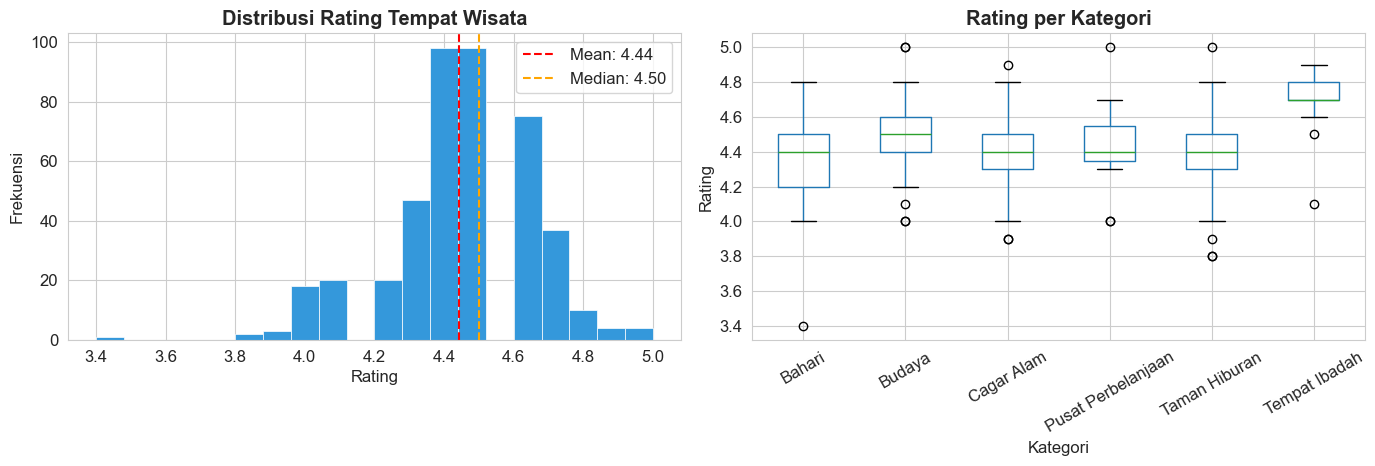


📌 Insight: Rating rata-rata 4.44 dari 5.0 — dataset berkualitas tinggi


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram rating
axes[0].hist(tourism['Rating'], bins=20, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].axvline(tourism['Rating'].mean(), color='red', linestyle='--', label=f'Mean: {tourism["Rating"].mean():.2f}')
axes[0].axvline(tourism['Rating'].median(), color='orange', linestyle='--', label=f'Median: {tourism["Rating"].median():.2f}')
axes[0].set_title('Distribusi Rating Tempat Wisata', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot rating per kategori
tourism.boxplot(column='Rating', by='Category', ax=axes[1])
axes[1].set_title('Rating per Kategori', fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Rating')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('distribusi_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📌 Insight: Rating rata-rata {tourism["Rating"].mean():.2f} dari 5.0 — dataset berkualitas tinggi')

## 💰 8. Distribusi Harga Tiket

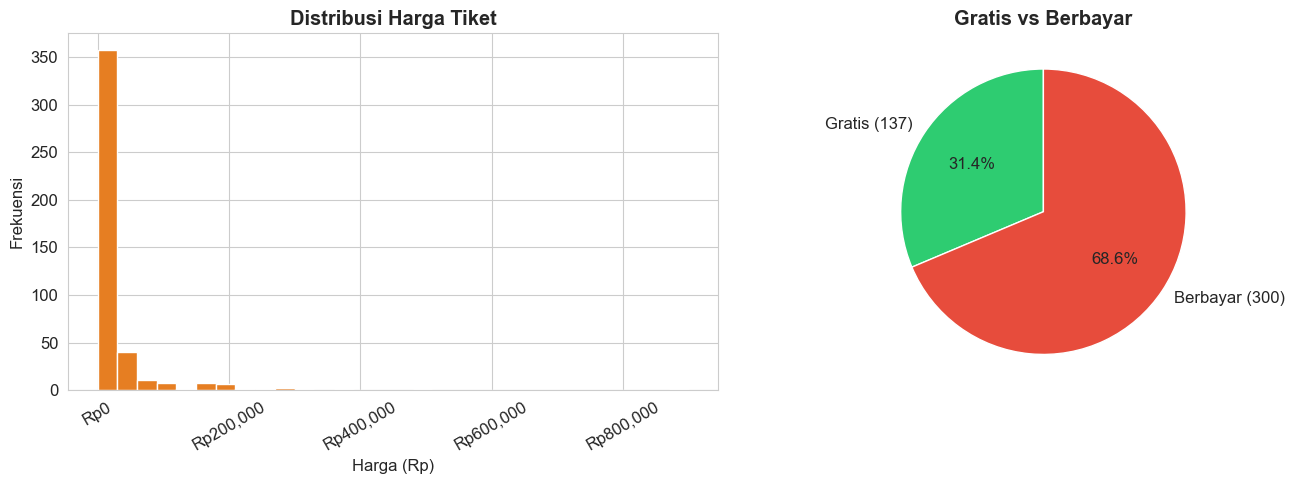


📌 Insight: 137 tempat wisata gratis (31.4%), 300 berbayar


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram harga
axes[0].hist(tourism['Price'], bins=30, color='#e67e22', edgecolor='white')
axes[0].set_title('Distribusi Harga Tiket', fontweight='bold')
axes[0].set_xlabel('Harga (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{int(x):,}'))
axes[0].tick_params(axis='x', rotation=30)

# Pie chart gratis vs berbayar
gratis = (tourism['Price'] == 0).sum()
berbayar = (tourism['Price'] > 0).sum()
axes[1].pie([gratis, berbayar],
            labels=[f'Gratis ({gratis})', f'Berbayar ({berbayar})'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Gratis vs Berbayar', fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_harga.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📌 Insight: {gratis} tempat wisata gratis ({gratis/len(tourism)*100:.1f}%), {berbayar} berbayar')

## ☁️ 9. Word Cloud Deskripsi Wisata

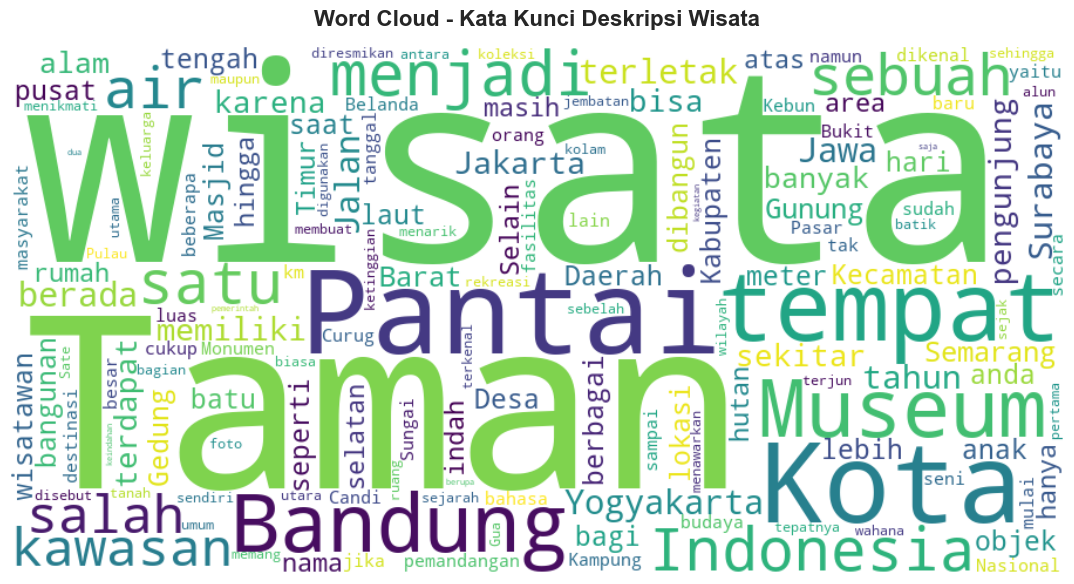


📌 Insight: Kata dominan mencerminkan kekayaan alam dan budaya Indonesia


In [11]:
# Gabungkan semua deskripsi
all_text = ' '.join(tourism['Description'].dropna().tolist())

# Stopwords sederhana
stopwords_id = {'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan',
                'adalah', 'pada', 'untuk', 'sebagai', 'juga', 'telah', 'akan',
                'dapat', 'dalam', 'atau', 'oleh', 'tidak', 'ada', 'ini', 'tersebut',
                'sangat', 'serta', 'merupakan', 'para', 'the', 'of', 'and', 'in',
                'a', 'to', 'is', 'as', 'an', 'are', 'has', 'have', 'been', 'its'}

wordcloud = WordCloud(
    width=900, height=450,
    background_color='white',
    stopwords=stopwords_id,
    colormap='viridis',
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Kata Kunci Deskripsi Wisata', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Kata dominan mencerminkan kekayaan alam dan budaya Indonesia')

## 🗺️ 10. Analisis Keyword di Nama Tempat

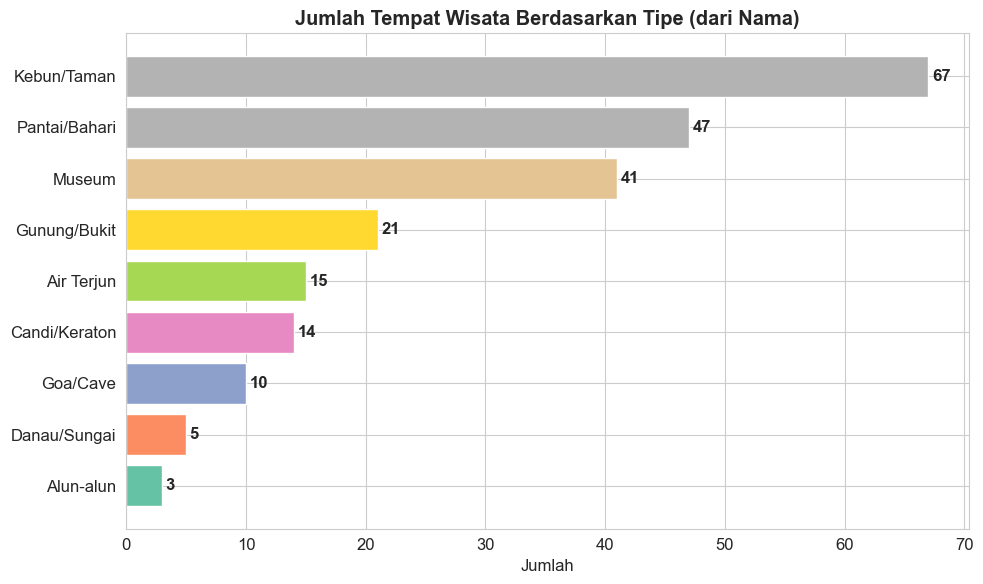


📌 Insight: Pantai/Bahari mendominasi, diikuti Kebun/Taman dan Gunung/Bukit


In [12]:
# Cek kata kunci di nama tempat
keywords = {
    'Pantai/Bahari': ['pantai', 'beach', 'laut', 'pulau'],
    'Gunung/Bukit':  ['gunung', 'bukit', 'puncak', 'mountain'],
    'Air Terjun':    ['air terjun', 'curug', 'waterfall'],
    'Goa/Cave':      ['goa', 'gua', 'cave'],
    'Danau/Sungai':  ['danau', 'sungai', 'lake', 'river', 'telaga'],
    'Alun-alun':     ['alun'],
    'Kebun/Taman':   ['kebun', 'taman', 'garden'],
    'Museum':        ['museum'],
    'Candi/Keraton': ['candi', 'keraton', 'istana', 'pura'],
}

hasil = {}
for label, words in keywords.items():
    mask = tourism['Place_Name'].str.lower().str.contains('|'.join(words), na=False)
    hasil[label] = mask.sum()

hasil_df = pd.DataFrame(list(hasil.items()), columns=['Tipe Wisata', 'Jumlah']).sort_values('Jumlah', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(hasil_df['Tipe Wisata'], hasil_df['Jumlah'],
                color=plt.cm.Set2(range(len(hasil_df))))
plt.title('Jumlah Tempat Wisata Berdasarkan Tipe (dari Nama)', fontweight='bold')
plt.xlabel('Jumlah')
for bar, val in zip(bars, hasil_df['Jumlah']):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('tipe_wisata.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Pantai/Bahari mendominasi, diikuti Kebun/Taman dan Gunung/Bukit')

## 📈 11. Analisis Rating Dataset

=== Analisis tourism_rating.csv ===
Total rating    : 10,000
Jumlah user     : 300
Jumlah tempat   : 437
Range rating    : 1 - 5


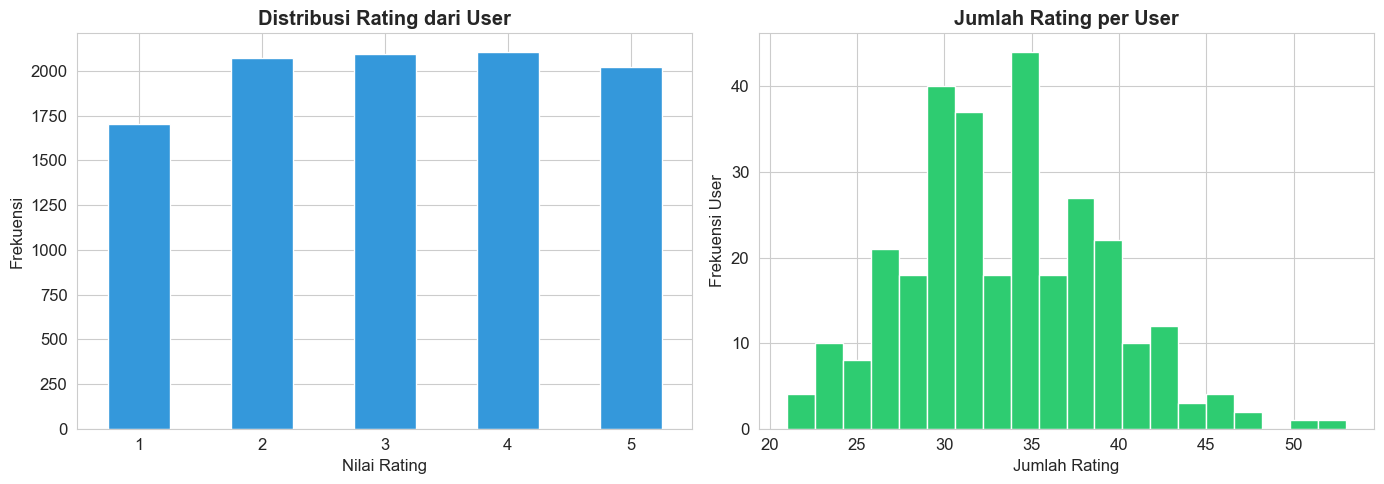


📌 Rata-rata rating per user: 33.3


In [13]:
print('=== Analisis tourism_rating.csv ===')
print(f'Total rating    : {len(rating):,}')
print(f'Jumlah user     : {rating["User_Id"].nunique()}')
print(f'Jumlah tempat   : {rating["Place_Id"].nunique()}')
print(f'Range rating    : {rating["Place_Ratings"].min()} - {rating["Place_Ratings"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi rating user
rating['Place_Ratings'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Distribusi Rating dari User', fontweight='bold')
axes[0].set_xlabel('Nilai Rating')
axes[0].set_ylabel('Frekuensi')
axes[0].tick_params(axis='x', rotation=0)

# Rating per user (histogram)
rating_per_user = rating.groupby('User_Id').size()
axes[1].hist(rating_per_user, bins=20, color='#2ecc71', edgecolor='white')
axes[1].set_title('Jumlah Rating per User', fontweight='bold')
axes[1].set_xlabel('Jumlah Rating')
axes[1].set_ylabel('Frekuensi User')

plt.tight_layout()
plt.savefig('analisis_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📌 Rata-rata rating per user: {rating_per_user.mean():.1f}')

## 📋 12. Ringkasan Temuan EDA

In [14]:
print('=' * 55)
print('         RINGKASAN TEMUAN EDA')
print('=' * 55)
print(f'📍 Total tempat wisata    : {len(tourism)} destinasi')
print(f'🏙️  Kota yang tercakup     : {tourism["City"].nunique()} kota')
print(f'🏷️  Jumlah kategori        : {tourism["Category"].nunique()} kategori')
print(f'⭐ Rating rata-rata       : {tourism["Rating"].mean():.2f} / 5.0')
print(f'💰 Tempat wisata gratis   : {(tourism["Price"]==0).sum()} ({(tourism["Price"]==0).mean()*100:.1f}%)')
print(f'📊 Total data rating      : {len(rating):,}')
print(f'👤 Jumlah user            : {rating["User_Id"].nunique()}')
print()
print('🔧 Hal yang perlu ditangani saat Preprocessing:')
print('   1. Hapus kolom tidak relevan (Unnamed: 11, Unnamed: 12)')
print('   2. Isi missing value Time_Minutes (232 data kosong)')
print('   3. Preprocessing teks deskripsi (stopword, stemming)')
print('   4. Normalisasi harga (range sangat lebar: 0 - 900.000)')
print()
print('✅ Dataset siap untuk tahap PREPROCESSING!')

         RINGKASAN TEMUAN EDA
📍 Total tempat wisata    : 437 destinasi
🏙️  Kota yang tercakup     : 5 kota
🏷️  Jumlah kategori        : 6 kategori
⭐ Rating rata-rata       : 4.44 / 5.0
💰 Tempat wisata gratis   : 137 (31.4%)
📊 Total data rating      : 10,000
👤 Jumlah user            : 300

🔧 Hal yang perlu ditangani saat Preprocessing:
   1. Hapus kolom tidak relevan (Unnamed: 11, Unnamed: 12)
   2. Isi missing value Time_Minutes (232 data kosong)
   3. Preprocessing teks deskripsi (stopword, stemming)
   4. Normalisasi harga (range sangat lebar: 0 - 900.000)

✅ Dataset siap untuk tahap PREPROCESSING!
